In [1]:
import os
import glob
import pandas as pd
import numpy as np

from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [2]:
# Path where all worker folders are stored
BASE_DIR = "../p2_reward"  # change to your main directory containing worker_0, worker_1, etc.
CSV_PATTERN = "worker_*/scores_per_image_timestep.csv"

csv_files = glob.glob(os.path.join(BASE_DIR, CSV_PATTERN))
print(f"Found CSVs: {csv_files}")

# Load all CSVs and concatenate
all_data = []
offset = 0
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    # Reindex images to make them unique across workers
    if df["image_idx"].notnull().any():
        df.loc[df["image_idx"].notnull(), "image_idx"] += offset
    # Compute offset: max image_idx in this df + 1
    if df["image_idx"].notnull().any():
        offset = df["image_idx"].max() + 1
    all_data.append(df)

all_data = pd.concat(all_data, ignore_index=True)

Found CSVs: ['../p2_reward/worker_0/scores_per_image_timestep.csv', '../p2_reward/worker_2/scores_per_image_timestep.csv', '../p2_reward/worker_1/scores_per_image_timestep.csv', '../p2_reward/worker_3/scores_per_image_timestep.csv']


# Define metrics

In [3]:
def avg_deviation_at_timestep(df: pd.DataFrame, timestep: int, metric_col: str = "reward") -> float:
    """
    Compute the average deviation of a metric for a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', metric_col]
        timestep: the timestep to compute the deviation for
        metric_col: metric column name (default: 'reward')

    Returns:
        float: average deviation Δ(metric) at the given timestep
    """
    # Original metric values (sample_idx is None)
    orig_metrics = df[df["sample_idx"].isnull()].set_index("image_idx")[metric_col].to_dict()
    
    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    delta_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
        orig_value = orig_metrics[img_idx]
        delta_list.append(np.mean(np.abs(samples - orig_value)))

    return float(np.mean(delta_list))


In [4]:
def entropy_at_timestep(df: pd.DataFrame, timestep: int, metric_col: str = "reward", num_bins: int = 10, value_min: float = 0.0, value_max: float = 1.0) -> float:
    """
    Compute the entropy of a metric across denoised samples at a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', metric_col]
        timestep: the timestep to compute entropy for
        metric_col: metric column name (default: 'reward')
        num_bins: number of bins to discretize the metric values (default: 10).
        value_min: minimum value of the binning range (inclusive).
        value_max: maximum value of the binning range (inclusive).

    Returns:
        float: average entropy H_R(t) across all images at the given timestep
    """
    from scipy.stats import entropy

    # Validate range
    if value_max <= value_min:
        raise ValueError("value_max must be greater than value_min")

    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]

    # If no denoised samples at this timestep, return 0.0
    if t_df.empty:
        raise ValueError(f"No denoised samples found at timestep {timestep} for metric '{metric_col}'.")

    # Ensure ALL samples fall within the specified [value_min, value_max] range
    out_of_range_mask = (t_df[metric_col] < value_min) | (t_df[metric_col] > value_max)
    if out_of_range_mask.any():
        n_out = int(out_of_range_mask.sum())
        n_total = int(len(t_df))
        raise ValueError(f"Found {n_out}/{n_total} samples outside the range [{value_min}, {value_max}] at timestep {t} for metric '{metric_col}'. All samples must be within the specified range.")

    ent_list = []
    # Create bin edges from value_min to value_max (num_bins bins -> num_bins+1 edges)
    bins = np.linspace(float(value_min), float(value_max), num_bins + 1)

    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
        
        # At this point all samples are guaranteed within range (checked above)
        # Compute histogram of samples using fixed bin edges
        hist, _ = np.histogram(samples, bins=bins, density=True)
        hist = hist.astype(float)
        hist += 1e-12  # avoid log(0)
        
        # Compute entropy
        ent_list.append(entropy(hist, base=np.e))

    # Average entropy across all images (should not be empty because t_df was not empty)
    return float(np.mean(ent_list))

In [5]:
def variance_at_timestep(df: pd.DataFrame, timestep: int, metric_col: str = "reward") -> float:
    """
    Compute the average variance of a metric across denoised samples at a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', metric_col]
        timestep: the timestep to compute variance for
        metric_col: metric column name (default: 'reward')

    Returns:
        float: average variance across all images at the given timestep
    """
    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    var_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
        var_list.append(np.var(samples, ddof=0))  # population variance

    # Average variance across all images
    return float(np.mean(var_list))


# Define plots

In [6]:
def plot_reward_histograms_with_original(df, timesteps=None, metric_col="reward", num_bins=10, value_min=None, value_max=None, image_idxs=None):
    """
    Plot histograms of rewards per image at each timestep with the original reward marked.

    This function will derive bin edges from `value_min`/`value_max` if provided,
    or try to use the `RANGES` dictionary (if defined in the notebook). If neither is
    available it falls back to the column min/max in `df`.

    Args:
        df: DataFrame containing the samples
        timesteps: list of timesteps to plot (defaults to sorted unique timesteps)
        metric_col: column name to plot
        num_bins: number of histogram bins (default: 10)
        value_min: optional minimum value for bins (inclusive)
        value_max: optional maximum value for bins (inclusive)
        image_idxs: optional list of image indices to include
    """
    sns.set(style="whitegrid", context="talk")

    if timesteps is None:
        timesteps = sorted(df["timestep"].dropna().unique().astype(int))

    # Determine value_min / value_max from arguments, RANGES (if present), or data
    if value_min is None or value_max is None:
        try:
            rng = RANGES.get(metric_col, None)  # RANGES may be defined in another cell
        except NameError:
            rng = None
        if rng is not None and value_min is None and value_max is None:
            value_min, value_max = float(rng[0]), float(rng[1])
        else:
            # Fall back to data-driven range
            col = df[metric_col].dropna()
            value_min = float(col.min()) if value_min is None else float(value_min)
            value_max = float(col.max()) if value_max is None else float(value_max)

    if value_max <= value_min:
        # Prevent degenerate bins; expand a tiny bit
        value_max = value_min + 1e-6

    # Create bin edges
    bin_edges = np.linspace(value_min, value_max, num_bins + 1)

    # Map image_idx -> original reward
    orig_metrics = df[df["sample_idx"].isnull()].set_index("image_idx")[metric_col].to_dict()

    palette = sns.color_palette("Blues", n_colors=5)

    for t in timesteps:
        t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == t)]
        images = sorted(t_df["image_idx"].unique())

        if image_idxs is not None:
            images = [img for img in images if img in image_idxs]

        if not images:
            continue

        num_images = len(images)
        fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 4), squeeze=False)

        for i, img_idx in enumerate(images):
            samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
            ax = axes[0, i]

            # Use the precomputed bin edges and set x-limits to the provided range
            if samples.size > 0:
                ax.hist(samples, bins=bin_edges, color=palette[3], edgecolor="black", alpha=0.8, density=True)
            else:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)

            orig_value = orig_metrics.get(img_idx, None)
            if orig_value is not None:
                ax.axvline(orig_value, color="crimson", linestyle="--", linewidth=2, label="Original reward")

            ax.set_title(f"Image {img_idx}", fontsize=14, fontweight="semibold")
            ax.set_xlabel(metric_col.capitalize(), fontsize=12)
            ax.set_ylabel("Density", fontsize=12)
            ax.set_xlim(value_min, value_max)
            ax.legend(frameon=True)
            ax.grid(alpha=0.3, linestyle=":")

        plt.suptitle(f"Timestep {t}: Distribution of {metric_col} per image", fontsize=16, fontweight="bold", y=1.05)
        plt.tight_layout()
        plt.show()

In [7]:
import os
from PIL import Image, ImageDraw, ImageFont

def make_reconstruction_gif(worker_id, image_id, plot_dir, timesteps, num_samples=5, gif_path=None):
    """
    Creates a GIF showing reconstructed images across timesteps for a given worker and image,
    with timestep labeled on each frame.

    Args:
        worker_id (int): Worker folder ID (e.g., 0, 1)
        image_id (int): Image index
        plot_dir (str): Base directory where worker folders are stored
        timesteps (list[int]): List of timesteps to include
        num_samples (int): Number of denoised samples per timestep to include in the grid
        gif_path (str): Optional path to save the GIF. If None, will save to plot_dir.
    """
    worker_folder = os.path.join(plot_dir, f"worker_{worker_id}", "recon_plots")
    frames = []
    text_height = 15  # smaller space for timestep label

    for t in timesteps:
        # Collect denoised sample images for this timestep and image
        imgs = []
        for sample_idx in range(num_samples):
            img_path = os.path.join(worker_folder, f"img{image_id}_t{t}_sample{sample_idx}.png")
            if os.path.exists(img_path):
                imgs.append(Image.open(img_path))
        
        if not imgs:
            continue  # Skip if no images found

        # Create horizontal grid
        widths, heights = zip(*(i.size for i in imgs))
        total_width = sum(widths)
        max_height = max(heights)
        grid_img = Image.new('RGB', (total_width, max_height + text_height), color=(255, 255, 255))
        x_offset = 0
        for im in imgs:
            grid_img.paste(im, (x_offset, text_height))  # leave space for text at top
            x_offset += im.width

        # Draw timestep text
        draw = ImageDraw.Draw(grid_img)
        try:
            font = ImageFont.truetype("arial.ttf", 14)
        except:
            font = ImageFont.load_default()
        draw.text((5, 0), f"Timestep: {t}", fill=(0, 0, 0), font=font)

        frames.append(grid_img)

    if not frames:
        print(f"No frames found for worker {worker_id} image {image_id}")
        return None

    if gif_path is None:
        gif_path = os.path.join(plot_dir, f"worker_{worker_id}", f"image_{image_id}_recon.gif")

    frames[0].save(
        gif_path, format='GIF',
        append_images=frames[1:], save_all=True,
        duration=500, loop=0
    )
    print(f"GIF saved to {gif_path}")
    return gif_path


# Save metrics stats

In [6]:
METRICS = ["reward"] + ["ir_person", "sex_score", "sex_score_binary", "aesthetics_score"]
RANGES = {}
for metric in METRICS:
    col_values = all_data[metric].dropna()
    RANGES[metric] = (col_values.min(), col_values.max())

In [7]:
# Get all unique timesteps in sorted order
timesteps = sorted(all_data["timestep"].dropna().unique().astype(int))

rows = []
for metric in METRICS:
    delta_values = [avg_deviation_at_timestep(all_data, timestep=t, metric_col=metric) for t in timesteps]
    variance_values = [variance_at_timestep(all_data, timestep=t, metric_col=metric) for t in timesteps]
    delta_values = np.array(delta_values)
    variance_values = np.array(variance_values)

    # --- Derivatives (forward difference, last value is np.nan) ---
    d_delta_diff = np.diff(delta_values) / np.diff(timesteps)
    d_variance_diff = np.diff(variance_values) / np.diff(timesteps)
    d_delta_diff = np.append(d_delta_diff, np.nan)
    d_variance_diff = np.append(d_variance_diff, np.nan)

    # --- Derivatives using np.gradient ---
    d_delta_grad = np.gradient(delta_values, timesteps)
    d_variance_grad = np.gradient(variance_values, timesteps)

    for i, t in enumerate(timesteps):
        rows.append({
            "timestep": t,
            "metric": metric,
            "avg_deviation": delta_values[i],
            "variance": variance_values[i],
            "d_avg_deviation_diff": d_delta_diff[i],
            "d_variance_diff": d_variance_diff[i],
            "d_avg_deviation_grad": d_delta_grad[i],
            "d_variance_grad": d_variance_grad[i]
        })

df_metrics = pd.DataFrame(rows)
# df_metrics.to_csv("timestep_metric_stats.csv", index=False)
# print("CSV saved as timestep_metric_stats.csv")
# df_metrics.head()


In [12]:
# Save a specific column (e.g., 'd_variance_diff') as JSON, with timesteps as keys
COLUMN_TO_SAVE = "avg_deviation"  # Change this to which column to save
METRIC = "reward"

df_metric = df_metrics[df_metrics["metric"] == METRIC]
out_dict = dict(zip(df_metric["timestep"].astype(int), df_metric[COLUMN_TO_SAVE]))
# Convert NaNs to None for valid JSON
for k, v in out_dict.items():
    if pd.isna(v):
        out_dict[k] = None

import json
with open(f"/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/{COLUMN_TO_SAVE}.json", "w") as f:
    json.dump(out_dict, f, indent=2)
print(f"Saved column '{COLUMN_TO_SAVE}' to p2_reward/{COLUMN_TO_SAVE}.json")


Saved column 'avg_deviation' to p2_reward/avg_deviation.json


# Analysis

In [10]:
df_metric

,timestep,metric,avg_deviation,variance,d_avg_deviation_diff,d_variance_diff,d_avg_deviation_grad,d_variance_grad
0,0,reward,0.039413,0.000825,0.001300,0.000135,0.001300,0.000135
1,20,reward,0.065422,0.003524,0.000810,0.000142,0.001055,0.000138
2,40,reward,0.081622,0.006355,0.000213,0.000065,0.000511,0.000103
3,60,reward,0.085878,0.007661,0.000656,0.000132,0.000435,0.000099
4,80,reward,0.099006,0.010302,0.000482,0.000035,0.000569,0.000084
5,100,reward,0.108636,0.011005,0.000240,0.000172,0.000361,0.000104
6,120,reward,0.113443,0.014446,0.000691,0.000249,0.000466,0.000211
7,140,reward,0.127270,0.019433,-0.000087,-0.000063,0.000302,0.000093
8,160,reward,0.125521,0.018170,-0.000083,-0.000009,-0.000085,-0.000036
9,180,reward,0.123865,0.017990,0.000092,-0.000146,0.000005,-0.000077


avg_deviation
variance


d_avg_deviation_diff
d_variance_diff
d_avg_deviation_grad
d_variance_grad


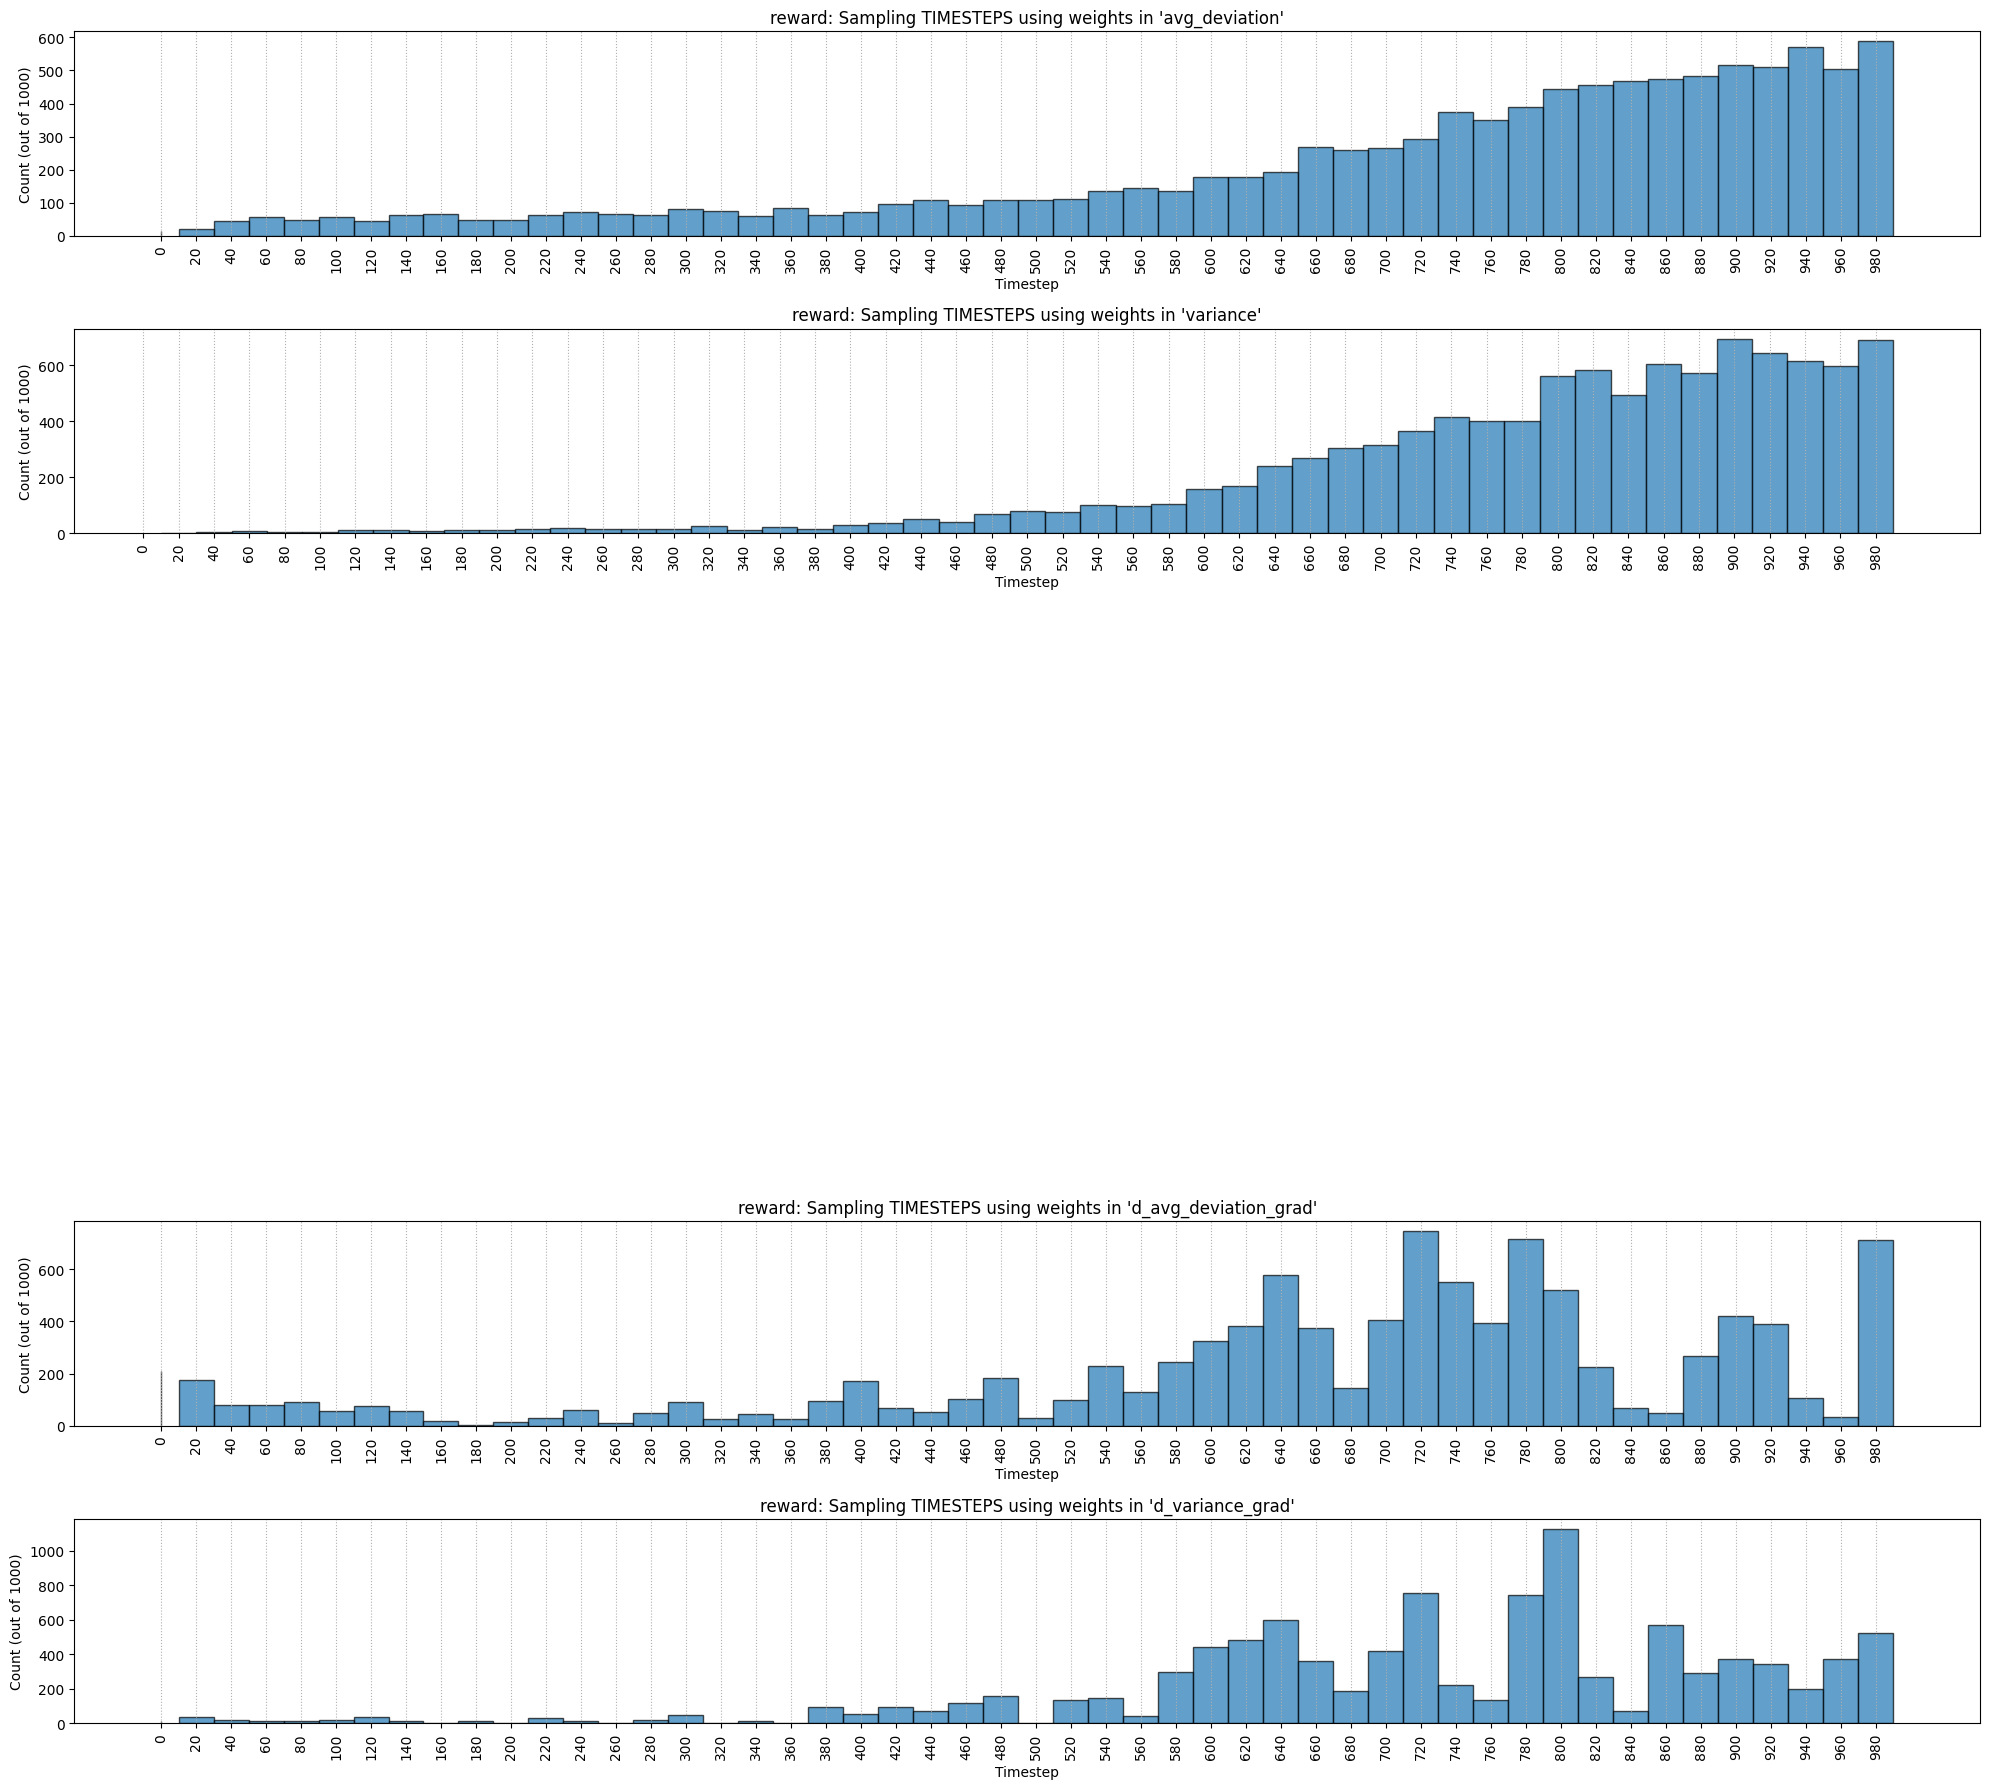

In [11]:
import torch

num_samples = 10000

for metric in ["reward"]: #METRICS:
    df_metric = df_metrics[df_metrics["metric"] == metric]
    
    # For each column in df_metric except 'timestep' and 'metric'
    columns = [col for col in df_metric.columns if col not in ["timestep", "metric"]]
    timesteps = df_metric["timestep"].values  # This is the ordered array of timesteps

    plt.figure(figsize=(20, 3 * len(columns)))
    for i, col in enumerate(columns):
        print(col)
        if "diff" in col:
            continue
        vals = df_metric[col].values
        # Convert to float and replace nan or inf with 0 for multinomial stability
        vals = pd.to_numeric(vals, errors='coerce').astype(float)
        vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        vals = np.abs(vals)
        weights = torch.tensor(vals, dtype=torch.float)
        # If all weights <= 0, multinomial will fail. To prevent, add eps or skip.
        if not torch.any(weights > 0):
            samples = ["all_zero_weights"]
        else:
            samples = torch.multinomial(weights, num_samples=num_samples, replacement=True).numpy()
        
        plt.subplot(len(columns), 1, i+1)
        if isinstance(samples, list):
            plt.text(0.5, 0.5, "All zero weights", fontsize=16, ha="center")
            plt.title(f"{metric}: {col} (all weights zero)")
            plt.xlabel("Timestep")
            plt.ylabel("Count (out of 1000)")
            plt.xticks(timesteps)
        else:
            # samples contains indices in the range [0, len(weights))
            # Map these to corresponding timestep values for x-axis
            sampled_timesteps = timesteps[samples]

            # Bin *exactly* at timesteps using a bar plot for precise labeling on x axis
            unique_timesteps, counts = np.unique(sampled_timesteps, return_counts=True)
            count_dict = dict(zip(unique_timesteps, counts))
            y_counts = np.array([count_dict.get(t, 0) for t in timesteps])

            plt.bar(timesteps, y_counts, color="tab:blue", edgecolor='black', alpha=0.7, align='center', width=np.diff(timesteps, prepend=timesteps[0]))
            plt.title(f"{metric}: Sampling TIMESTEPS using weights in '{col}'")
            plt.xlabel("Timestep")
            plt.ylabel("Count (out of 1000)")

            # Set x ticks at center of each timestep
            plt.xticks(timesteps, rotation=90 if len(timesteps) > 15 else 0)
        plt.grid(axis="x", linestyle=":")
    plt.tight_layout()
    plt.show()


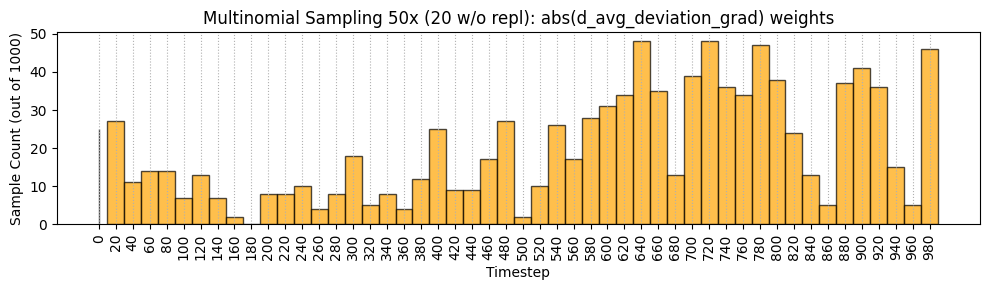

In [15]:
# Repeat multinomial sampling 50 times, each time sampling 20 timesteps without replacement,
# accumulate counts to show which timesteps are sampled most frequently.

metric = "reward"
df_metric = df_metrics[df_metrics["metric"] == metric]
timesteps = df_metric["timestep"].values
grad_vals = df_metric["d_avg_deviation_grad"].values

# Convert to float and handle nan/inf, then abs
grad_vals = pd.to_numeric(grad_vals, errors='coerce').astype(float)
grad_vals = np.nan_to_num(grad_vals, nan=0.0, posinf=0.0, neginf=0.0)
weights = np.abs(grad_vals)
weights_tensor = torch.tensor(weights, dtype=torch.float)

n_sample = min(20, (weights > 0).sum())  # Only sample as many nonzero as possible

# Prepare to collect overall counts for each timestep
timestep_counts = np.zeros_like(timesteps, dtype=int)
has_enough = torch.any(weights_tensor > 0) and (weights > 0).sum() >= 20

if has_enough:
    for i in range(50):
        sample_indices = torch.multinomial(weights_tensor, num_samples=20, replacement=False).numpy()
        sampled_timesteps = timesteps[sample_indices]
        # Count for each sampled timestep
        unique_timesteps, counts = np.unique(sampled_timesteps, return_counts=True)
        count_dict = dict(zip(unique_timesteps, counts))
        timestep_counts += np.array([count_dict.get(t, 0) for t in timesteps])
else:
    sampled_timesteps = []

# Make a histogram (bar of counts per timestep) over all 50 x 20 samples
plt.figure(figsize=(10, 3))
if not has_enough:
    plt.text(0.5, 0.5, "Not enough nonzero weights", fontsize=15, ha='center')
else:
    plt.bar(timesteps, timestep_counts, width=np.diff(timesteps, prepend=timesteps[0]),
            color="orange", edgecolor="black", alpha=0.7)
    plt.xlabel("Timestep")
    plt.ylabel("Sample Count (out of 1000)")
    plt.title("Multinomial Sampling 50x (20 w/o repl): abs(d_avg_deviation_grad) weights")
    plt.xticks(timesteps, rotation=90 if len(timesteps) > 15 else 0)
plt.grid(axis="x", linestyle=":")
plt.tight_layout()
plt.show()


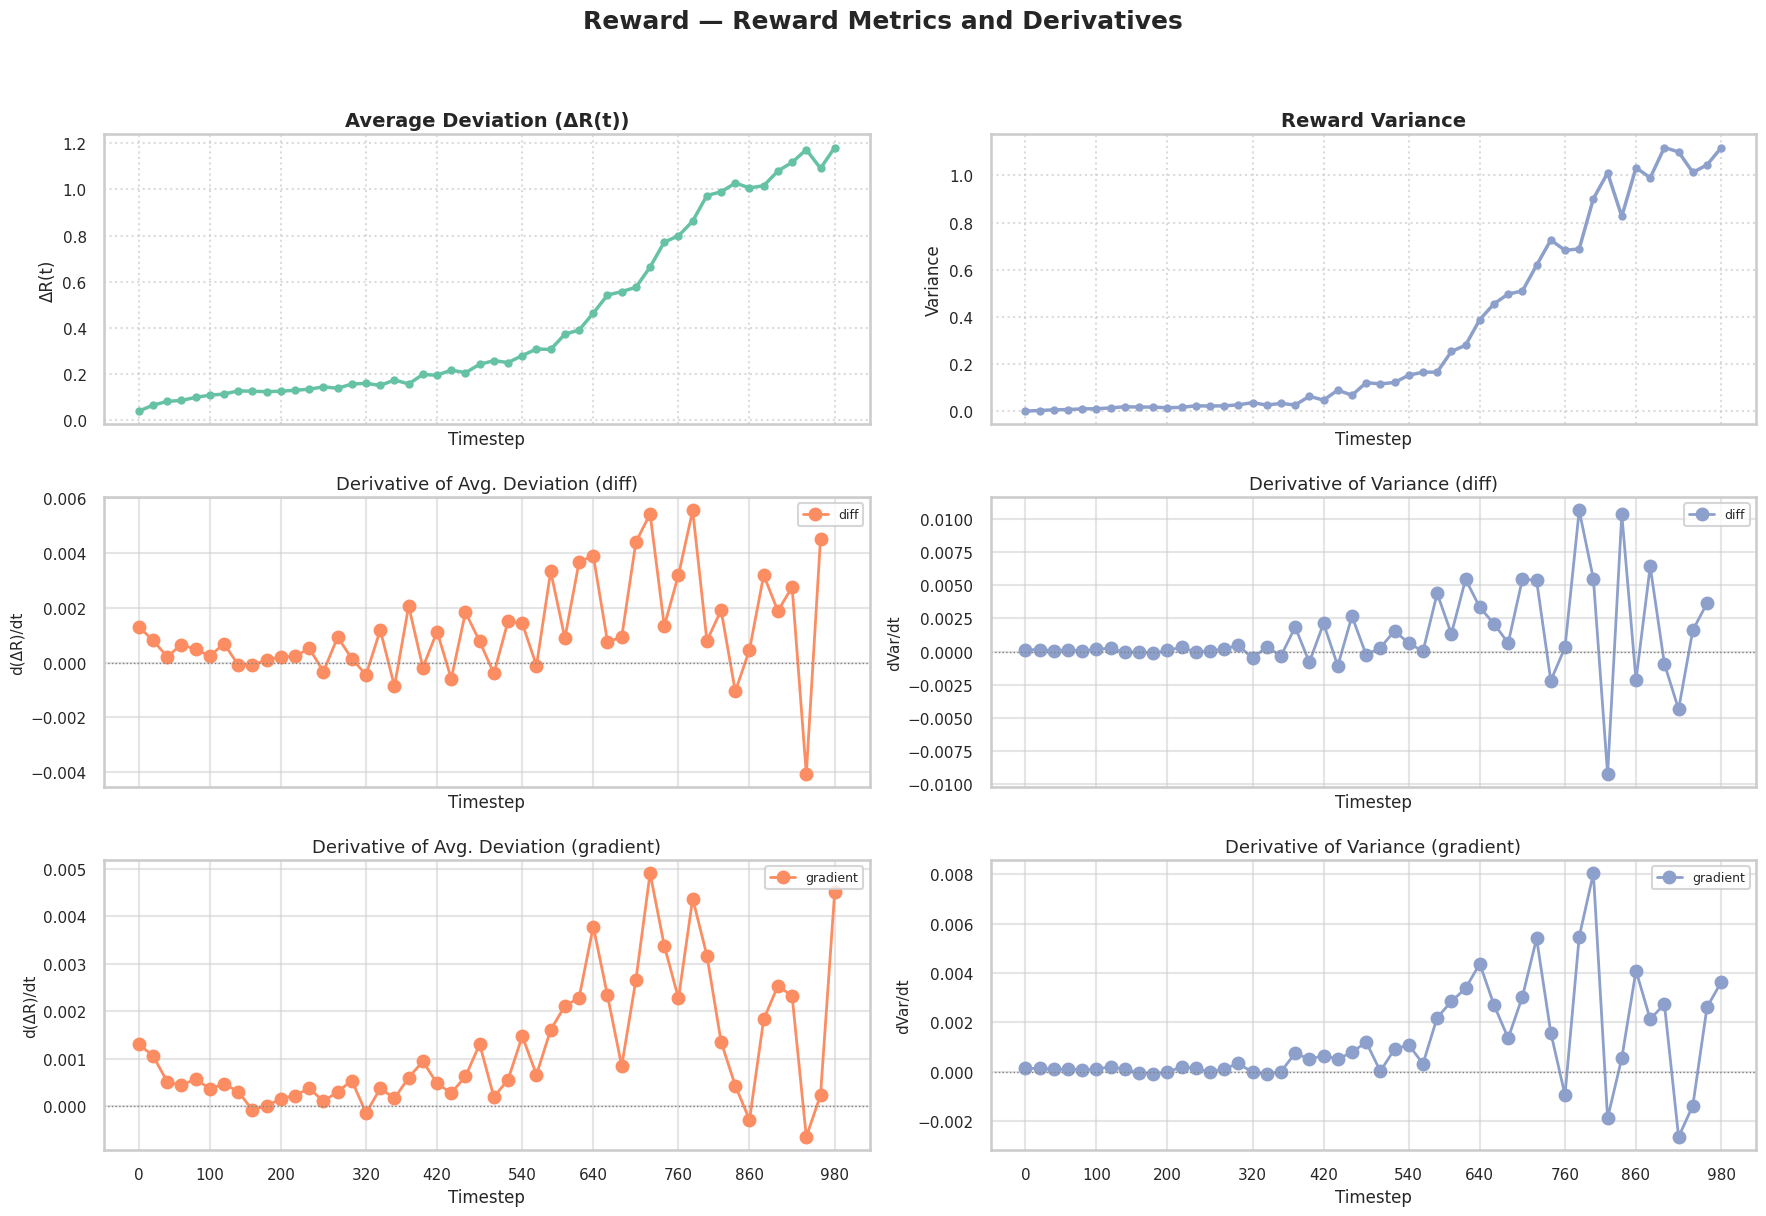

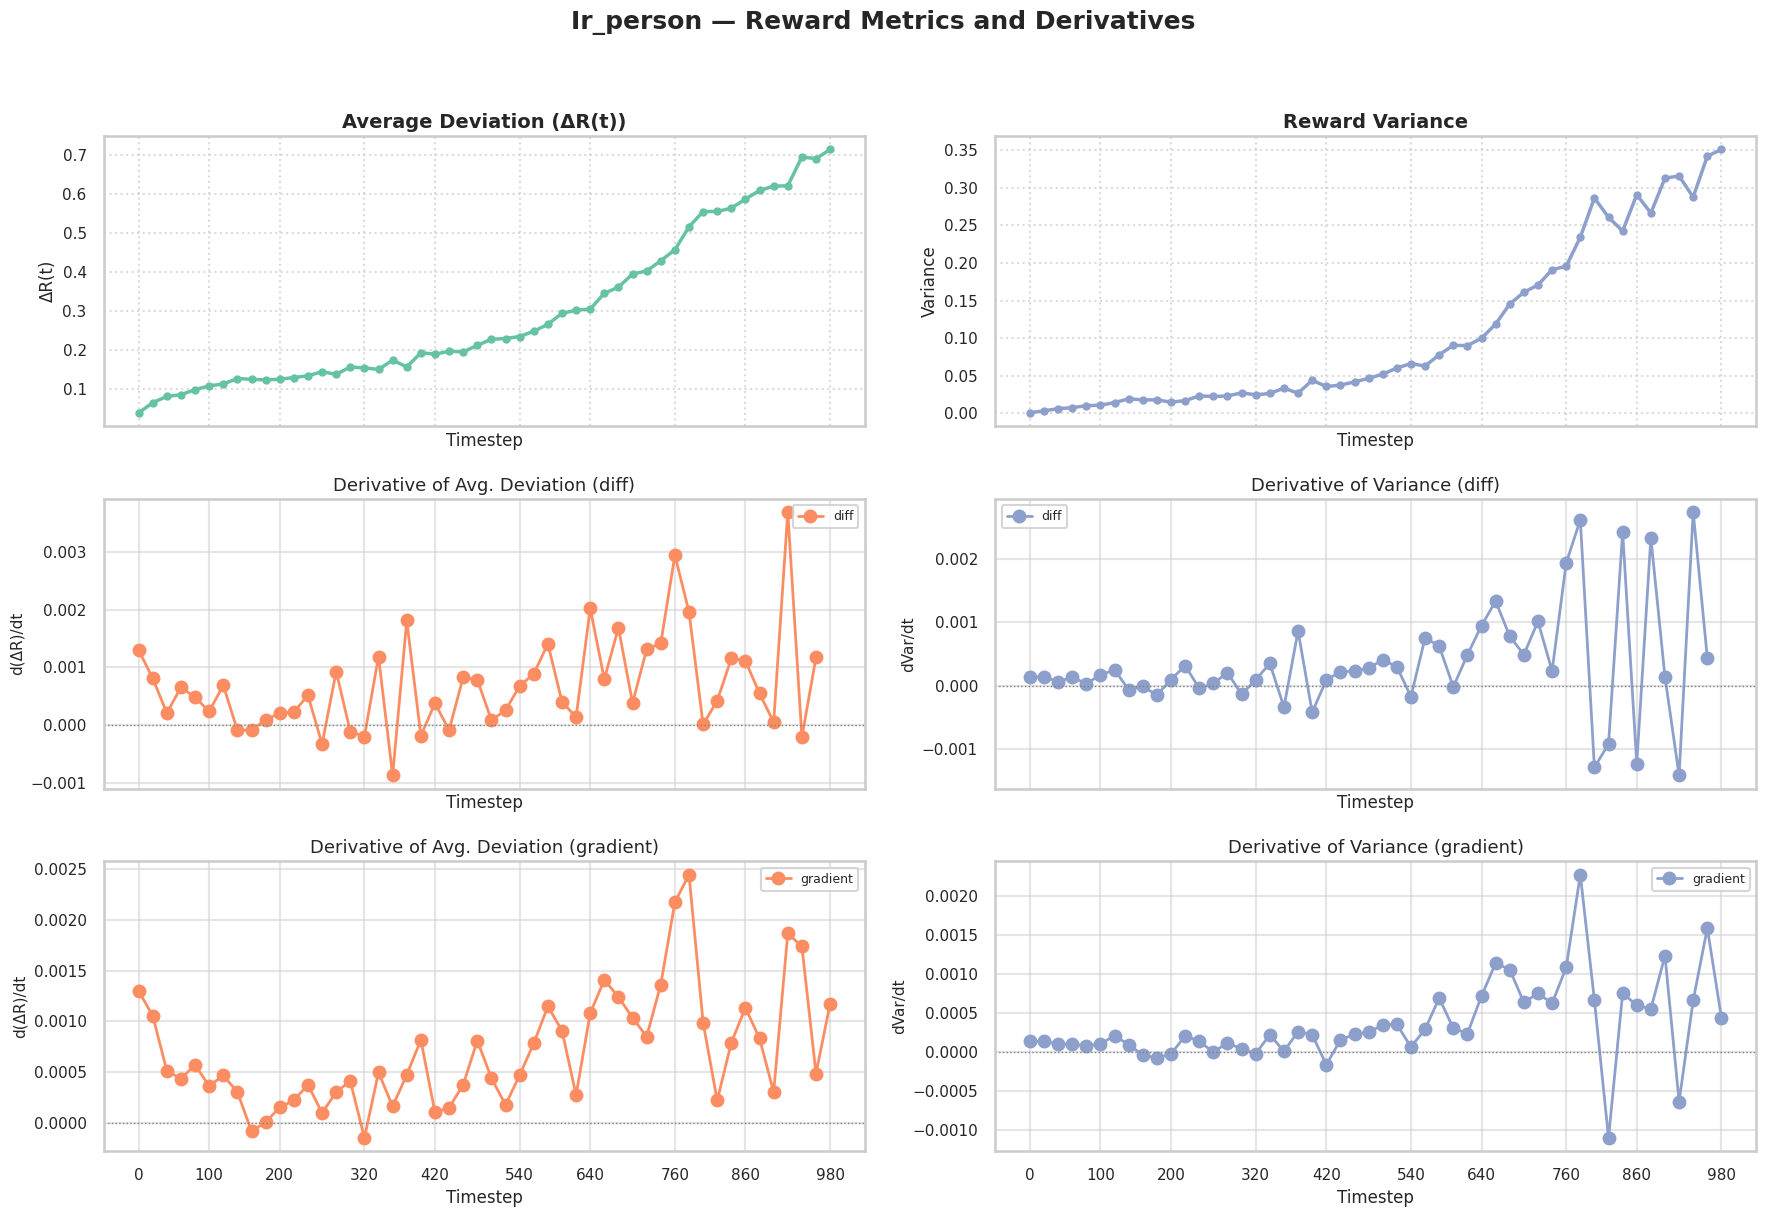

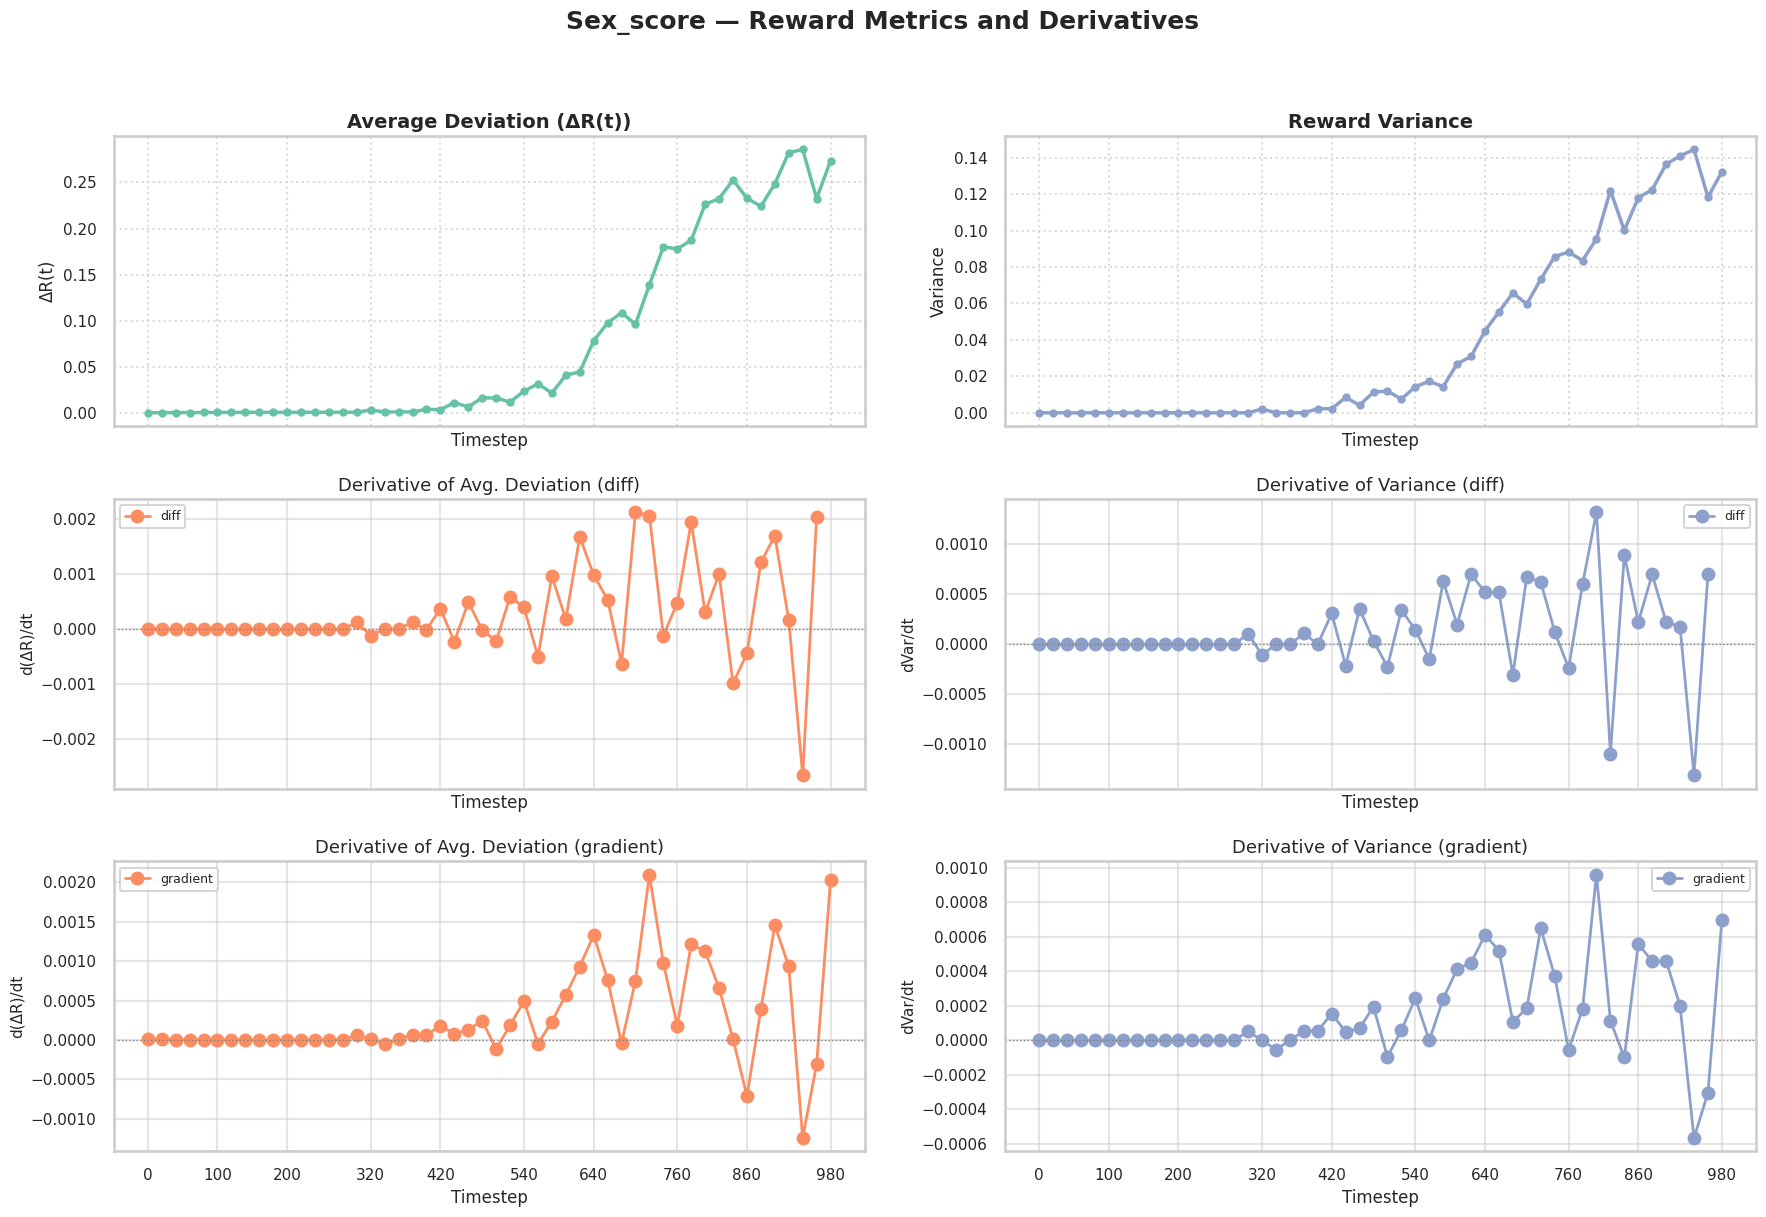

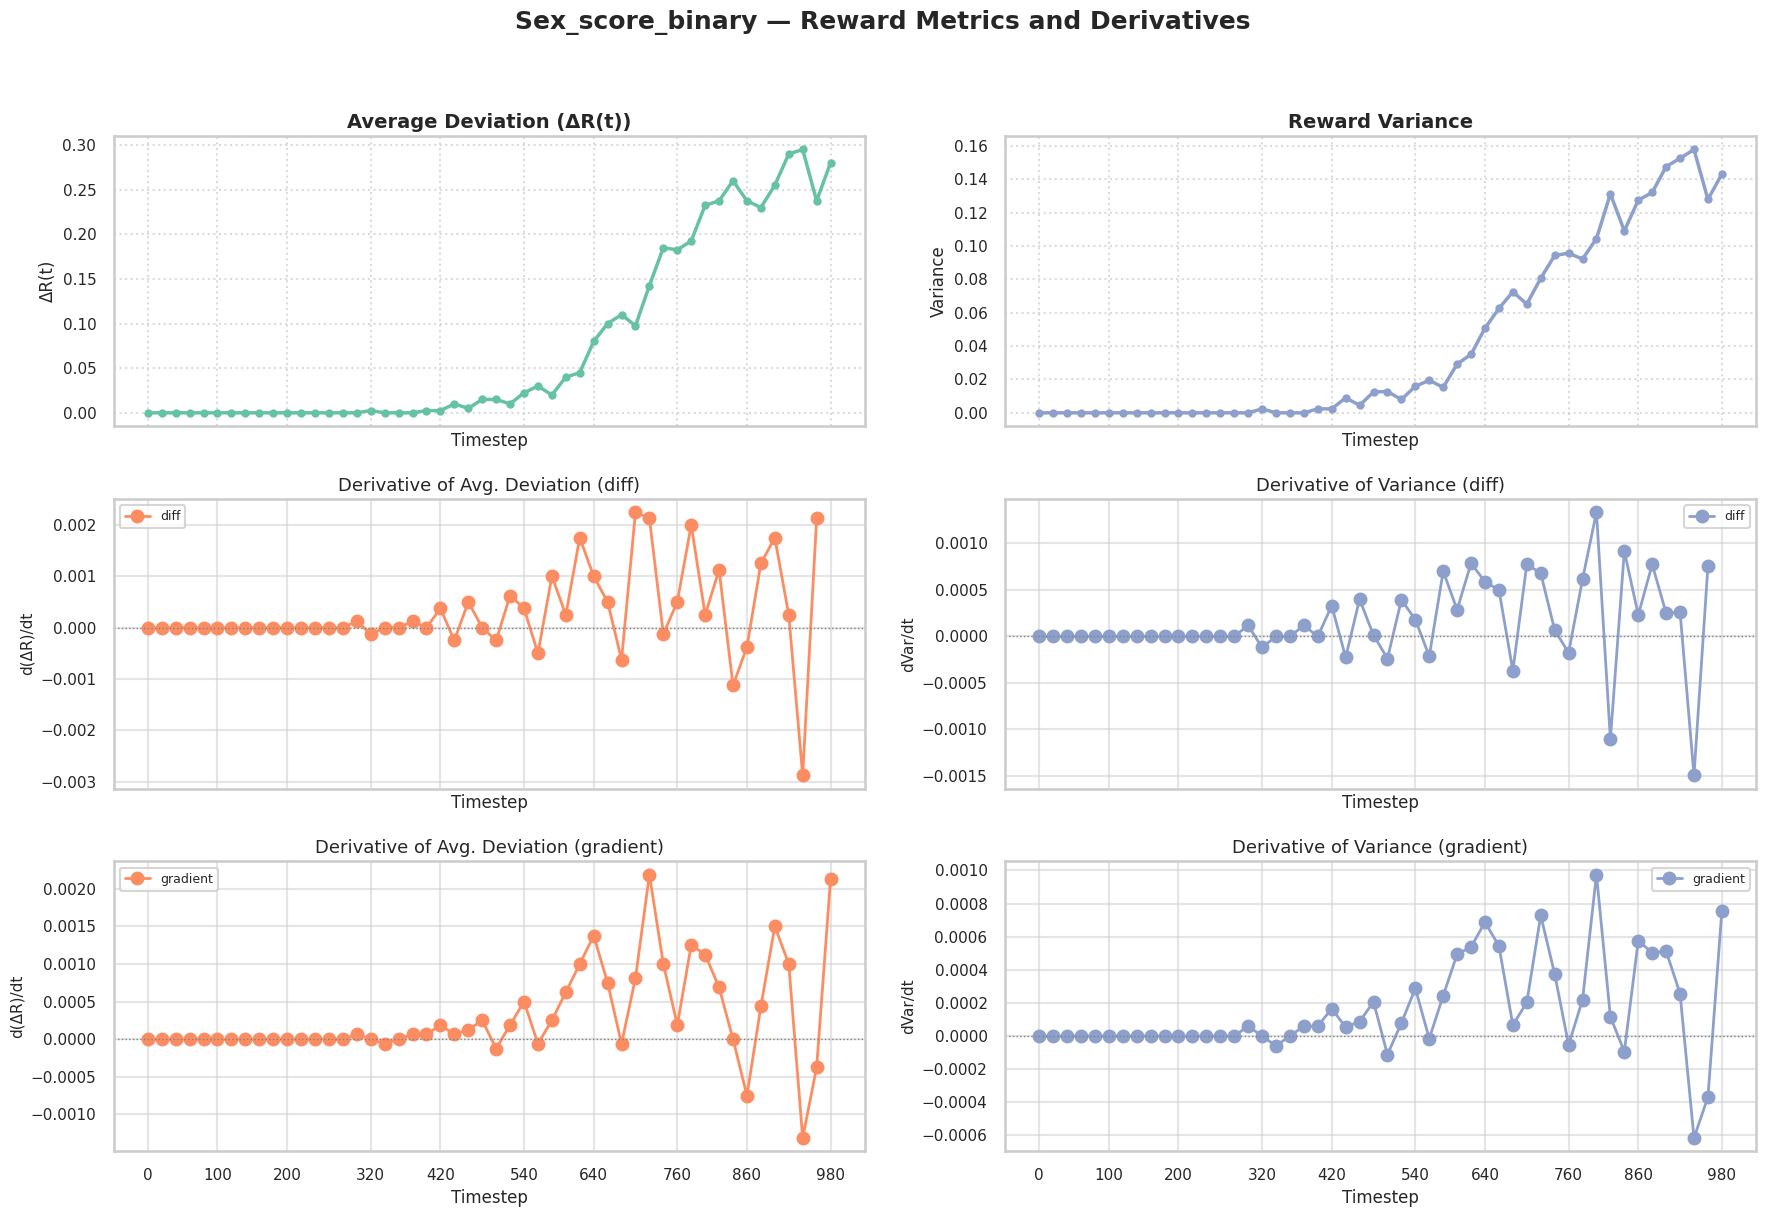

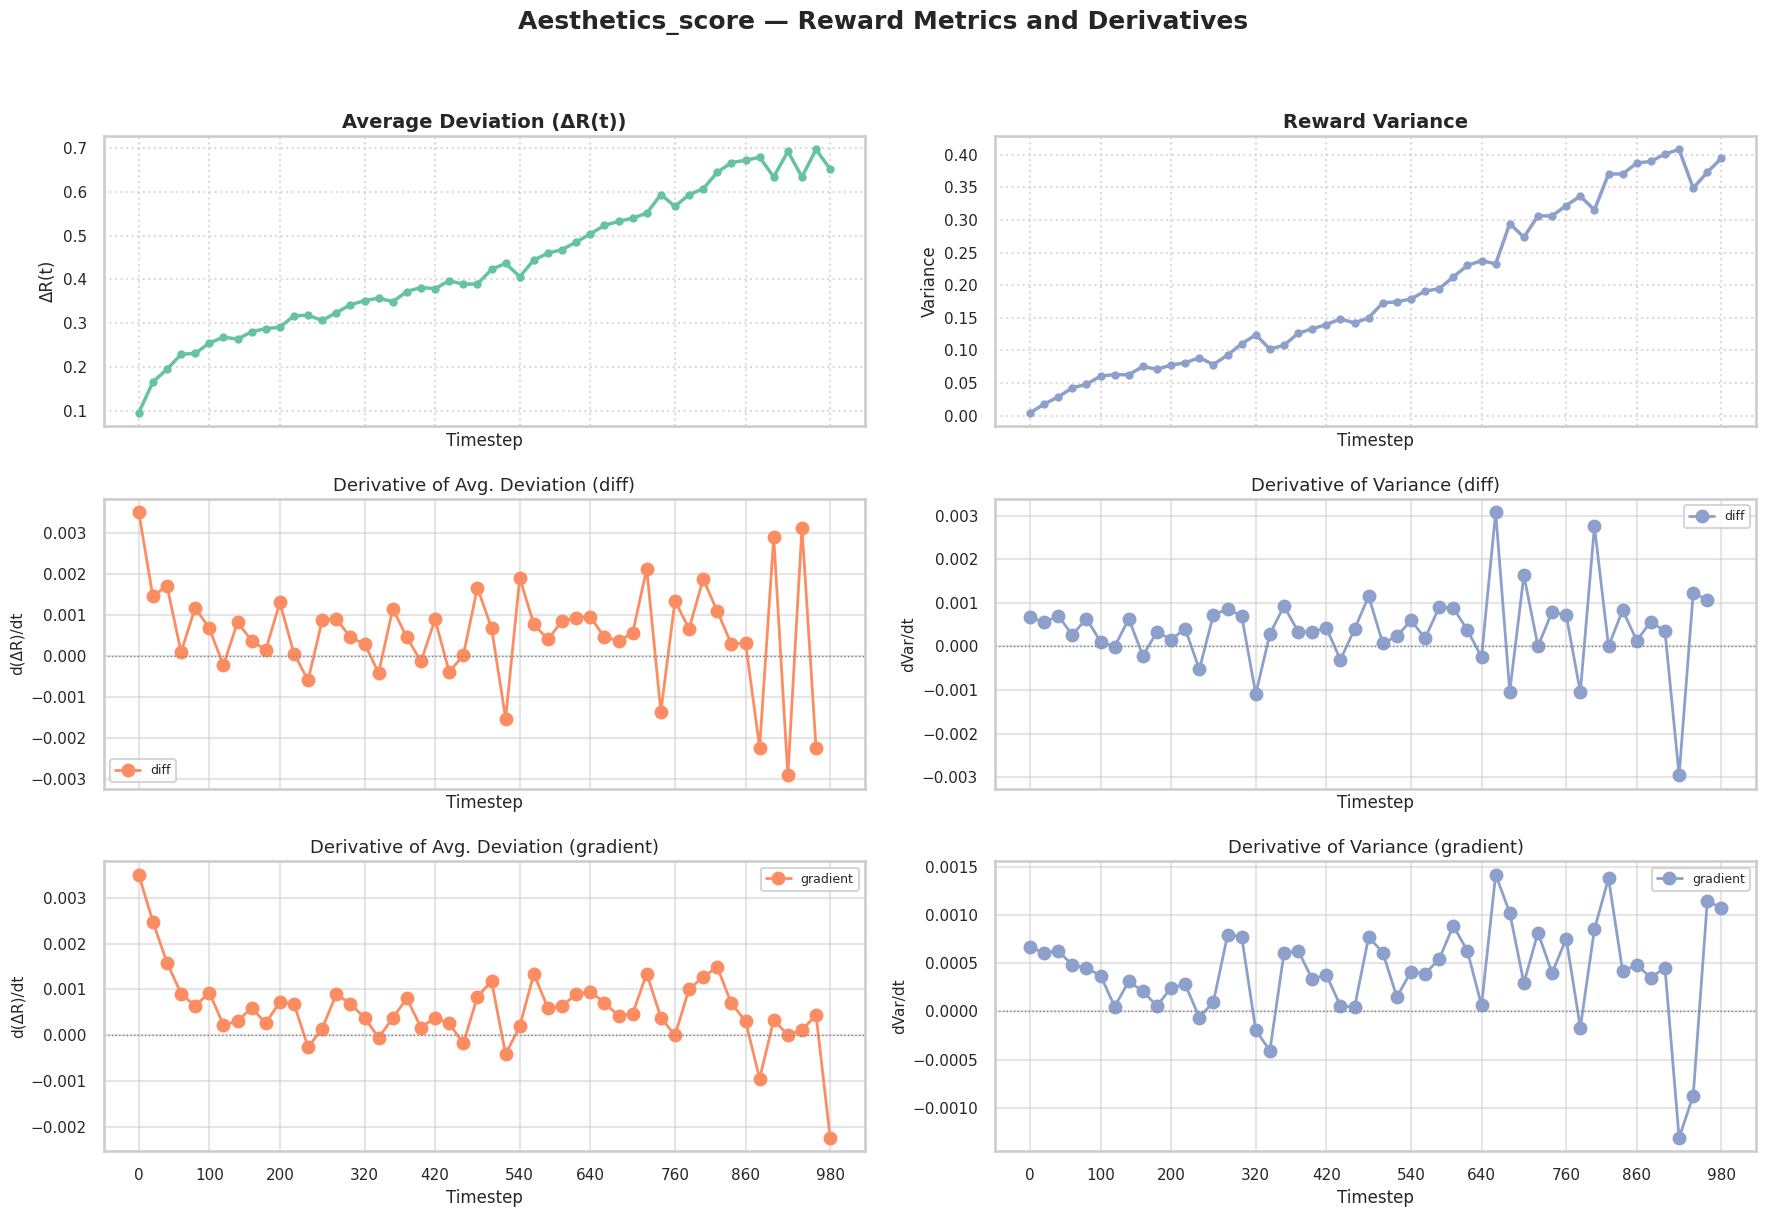

In [11]:
sns.set(style="whitegrid", context="talk")

for metric in METRICS:
    # Get the metric-specific DataFrame
    df_metric = df_metrics[df_metrics["metric"] == metric]

    # Extract values
    delta_values = df_metric["avg_deviation"].values
    variance_values = df_metric["variance"].values
    d_delta_diff = df_metric["d_avg_deviation_diff"].values
    d_variance_diff = df_metric["d_variance_diff"].values
    d_delta_grad = df_metric["d_avg_deviation_grad"].values
    d_variance_grad = df_metric["d_variance_grad"].values

    colors = sns.color_palette("Set2", 3)

    # 3 rows x 2 columns: metrics, diff derivatives, gradient derivatives
    fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=True)

    # --- Row 1: Base metrics ---
    axes[0, 0].plot(timesteps, delta_values, marker="o", markersize=5, linewidth=2.5, color=colors[0])
    axes[0, 0].set_title("Average Deviation (ΔR(t))", fontsize=14, fontweight="semibold")
    axes[0, 0].set_ylabel("ΔR(t)", fontsize=12)
    axes[0, 0].grid(True, alpha=0.7, linestyle=":")

    axes[0, 1].plot(timesteps, variance_values, marker="o", markersize=5, linewidth=2.5, color=colors[2])
    axes[0, 1].set_title("Reward Variance", fontsize=14, fontweight="semibold")
    axes[0, 1].set_ylabel("Variance", fontsize=12)
    axes[0, 1].grid(True, alpha=0.7, linestyle=":")

    # --- Row 2: Diff-based derivatives ---
    axes[1, 0].plot(timesteps, d_delta_diff, label='diff', linewidth=2, color=colors[1], marker='o')
    axes[1, 0].axhline(0, color='gray', linewidth=1, linestyle=':')
    axes[1, 0].set_title("Derivative of Avg. Deviation (diff)", fontsize=13)
    axes[1, 0].set_ylabel("d(ΔR)/dt", fontsize=11)
    axes[1, 0].grid(True, alpha=0.5)
    axes[1, 0].legend(fontsize=9)

    axes[1, 1].plot(timesteps, d_variance_diff, label='diff', linewidth=2, color=colors[2], marker='o')
    axes[1, 1].axhline(0, color='gray', linewidth=1, linestyle=':')
    axes[1, 1].set_title("Derivative of Variance (diff)", fontsize=13)
    axes[1, 1].set_ylabel("dVar/dt", fontsize=11)
    axes[1, 1].grid(True, alpha=0.5)
    axes[1, 1].legend(fontsize=9)

    # --- Row 3: Gradient-based derivatives ---
    axes[2, 0].plot(timesteps, d_delta_grad, label='gradient', linewidth=2, color=colors[1], marker='o')
    axes[2, 0].axhline(0, color='gray', linewidth=1, linestyle=':')
    axes[2, 0].set_title("Derivative of Avg. Deviation (gradient)", fontsize=13)
    axes[2, 0].set_ylabel("d(ΔR)/dt", fontsize=11)
    axes[2, 0].grid(True, alpha=0.5)
    axes[2, 0].legend(fontsize=9)

    axes[2, 1].plot(timesteps, d_variance_grad, label='gradient', linewidth=2, color=colors[2], marker='o')
    axes[2, 1].axhline(0, color='gray', linewidth=1, linestyle=':')
    axes[2, 1].set_title("Derivative of Variance (gradient)", fontsize=13)
    axes[2, 1].set_ylabel("dVar/dt", fontsize=11)
    axes[2, 1].grid(True, alpha=0.5)
    axes[2, 1].legend(fontsize=9)

    # Shared x-axis formatting
    num_ticks = min(10, len(timesteps))
    if num_ticks > 1:
        tick_indices = np.linspace(0, len(timesteps) - 1, num_ticks, dtype=int)
        ticks_to_show = [timesteps[i] for i in tick_indices]
    else:
        ticks_to_show = timesteps

    for row in axes:
        for ax in row:
            ax.set_xlabel("Timestep", fontsize=12)
            ax.tick_params(axis="both", labelsize=11)
            ax.set_xticks(ticks_to_show)
            ax.set_xticklabels(ticks_to_show, rotation=0)

    fig.suptitle(f"{metric.capitalize()} — Reward Metrics and Derivatives", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


Randomly sampled images (same across timesteps): [0, 17, 15, 1, 8]
Selected timesteps for histograms: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]


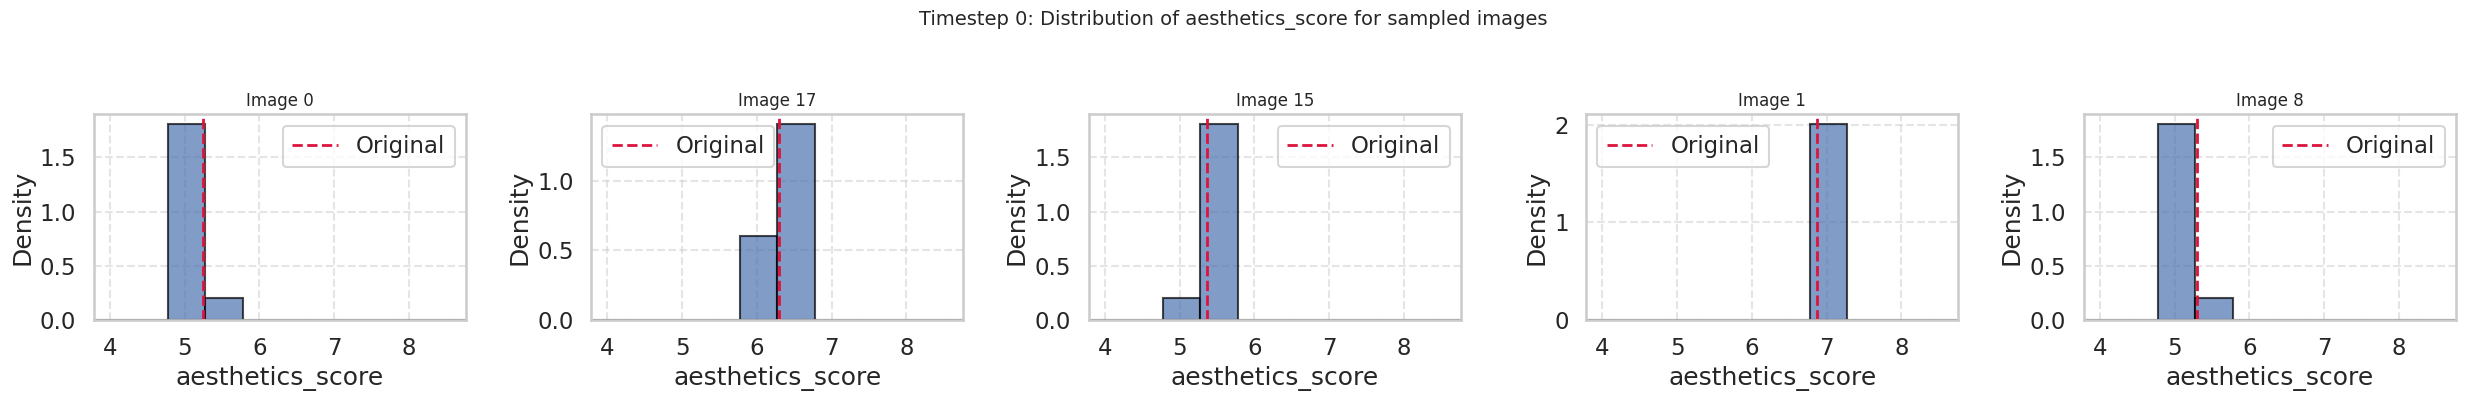

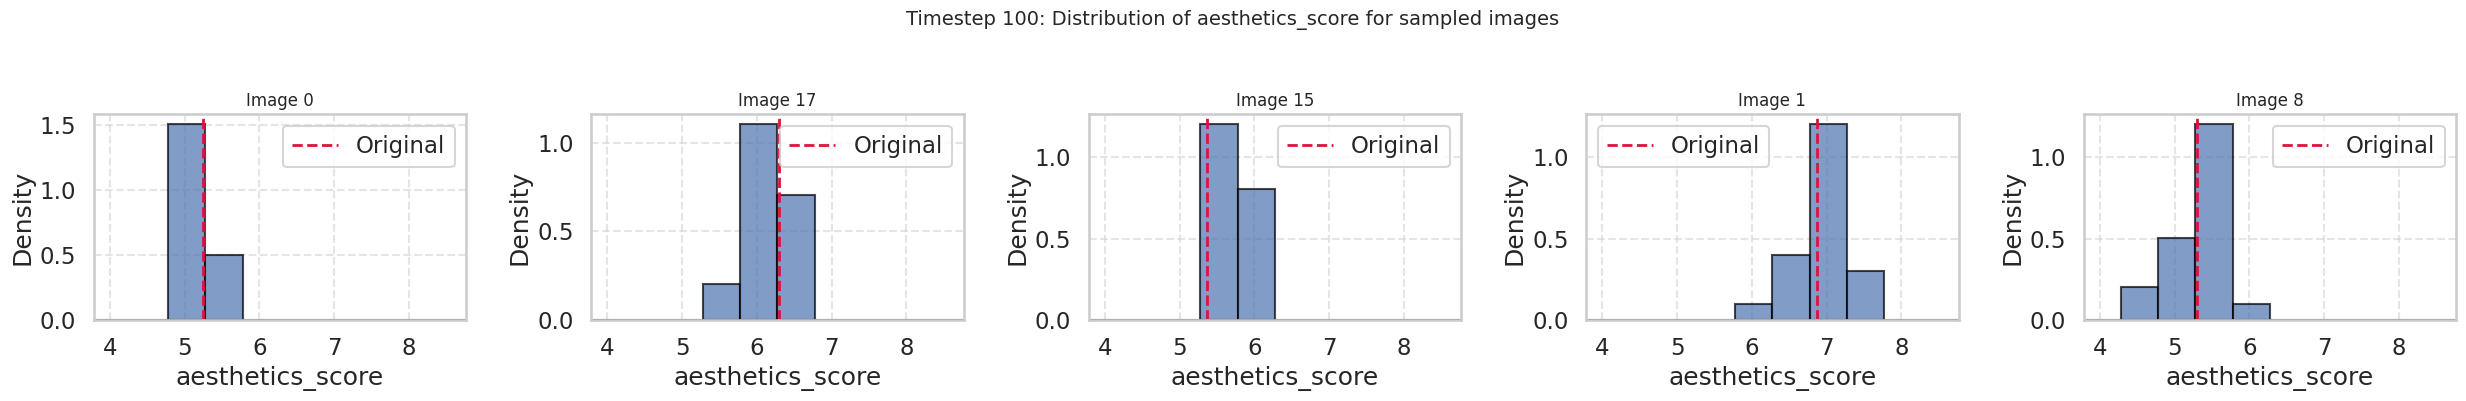

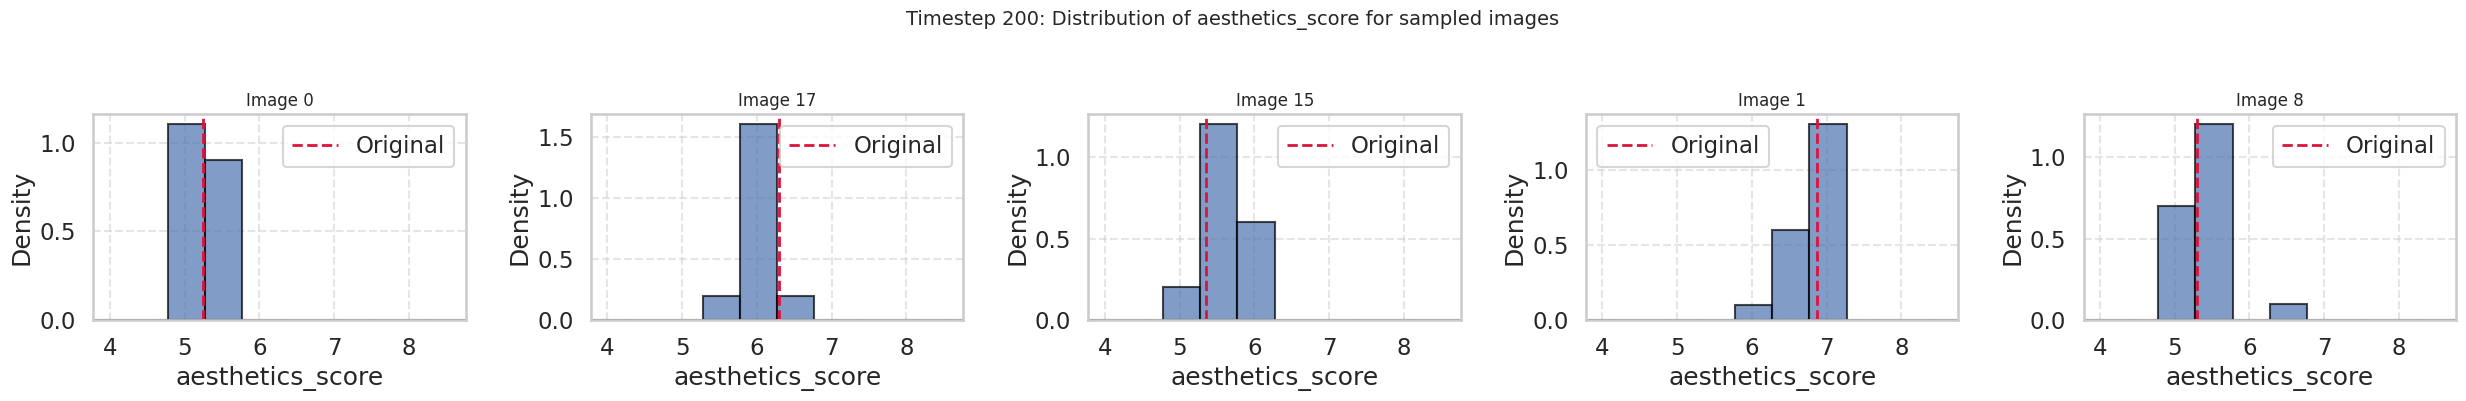

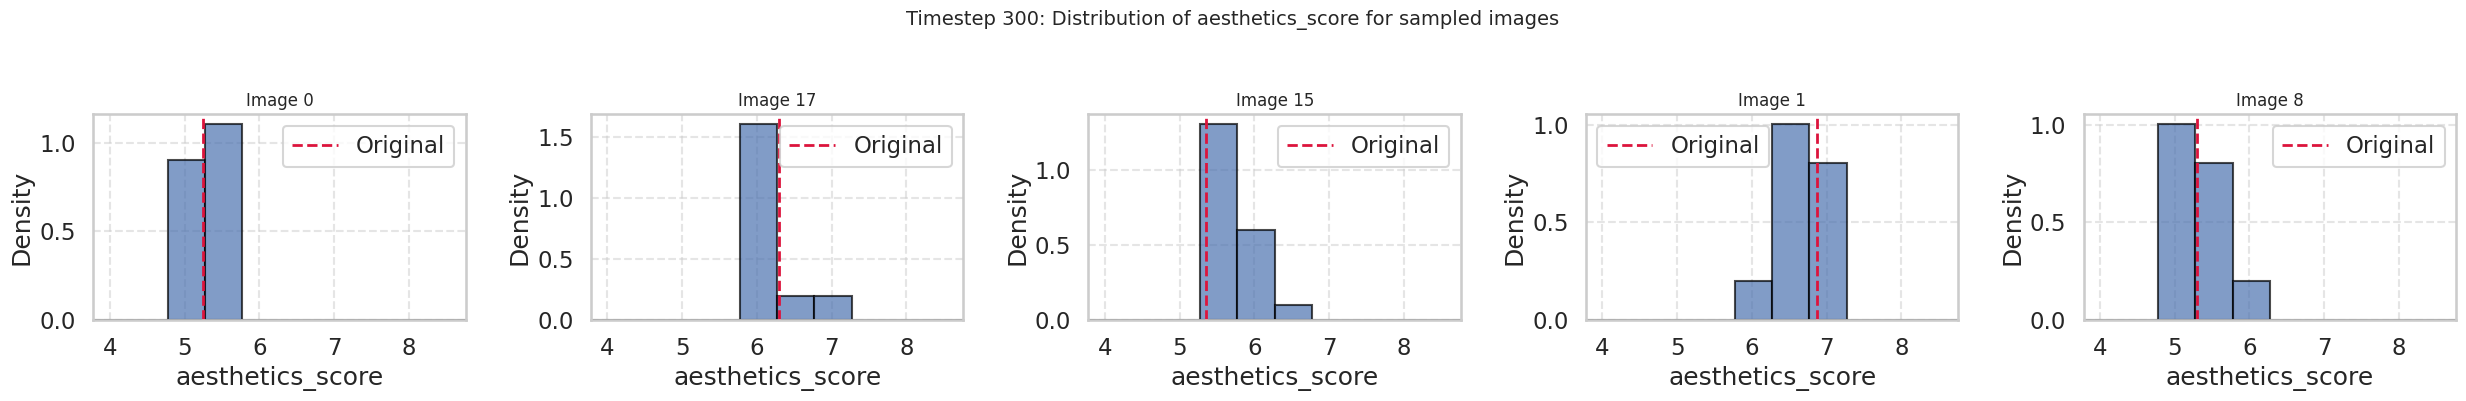

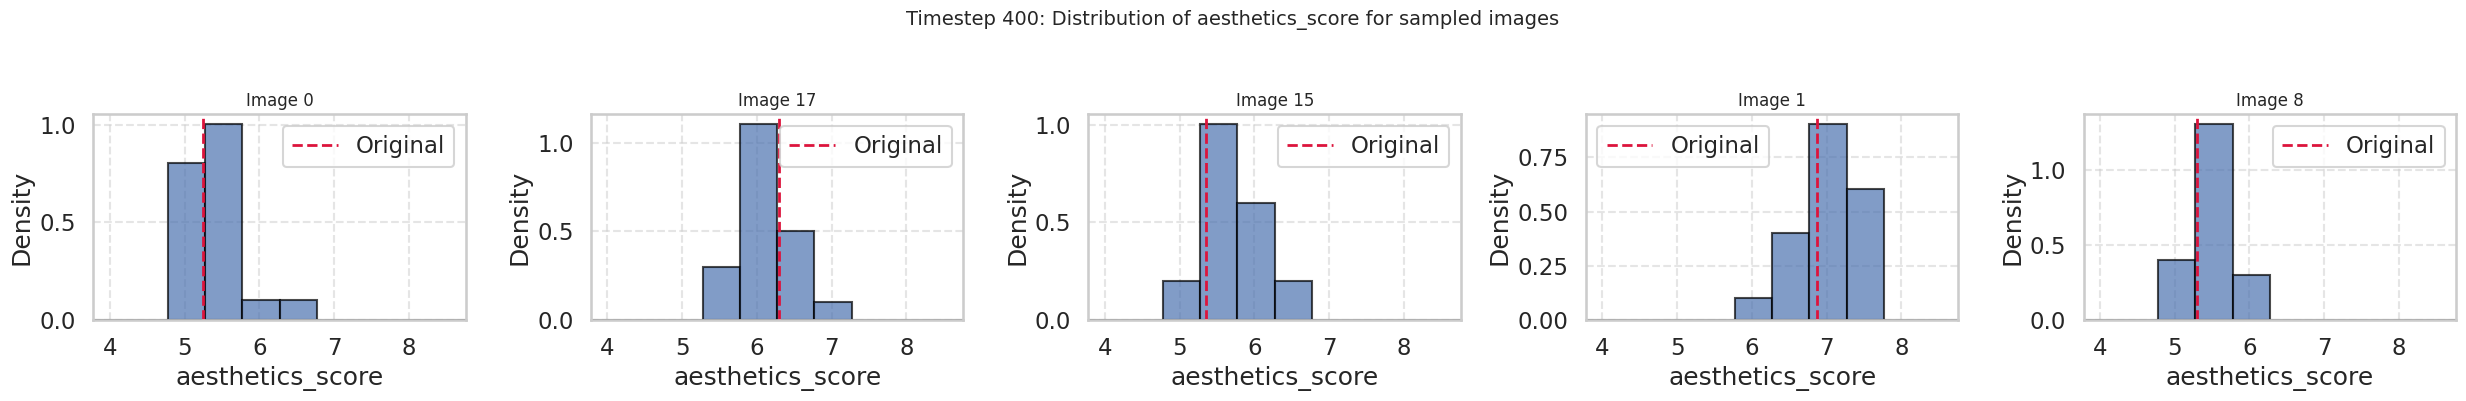

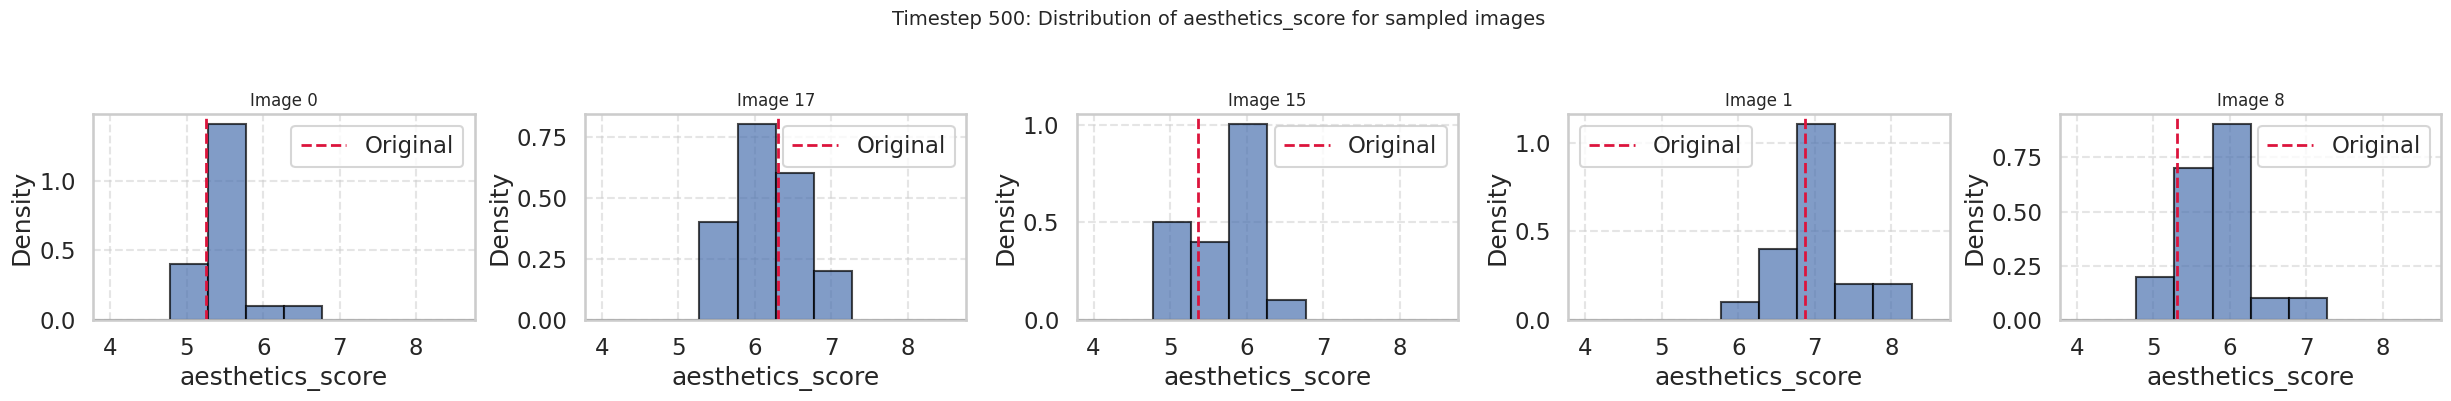

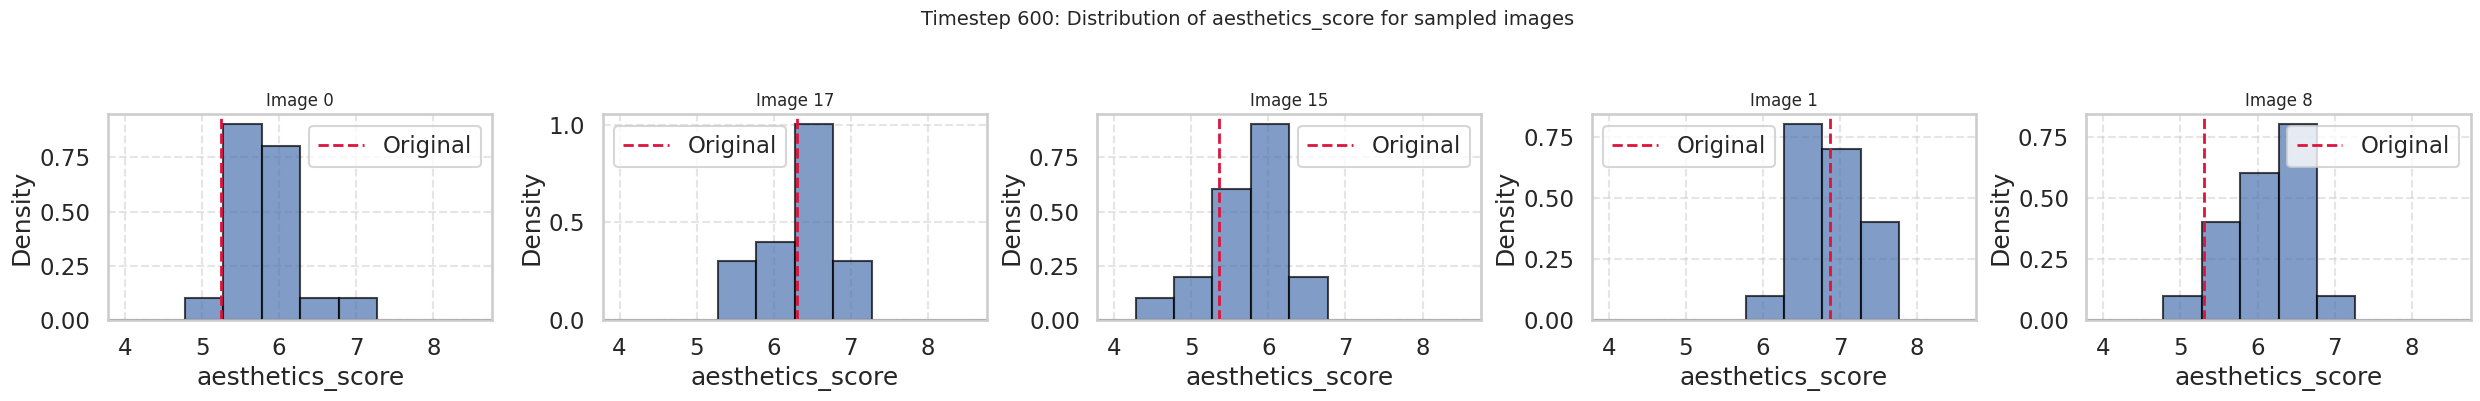

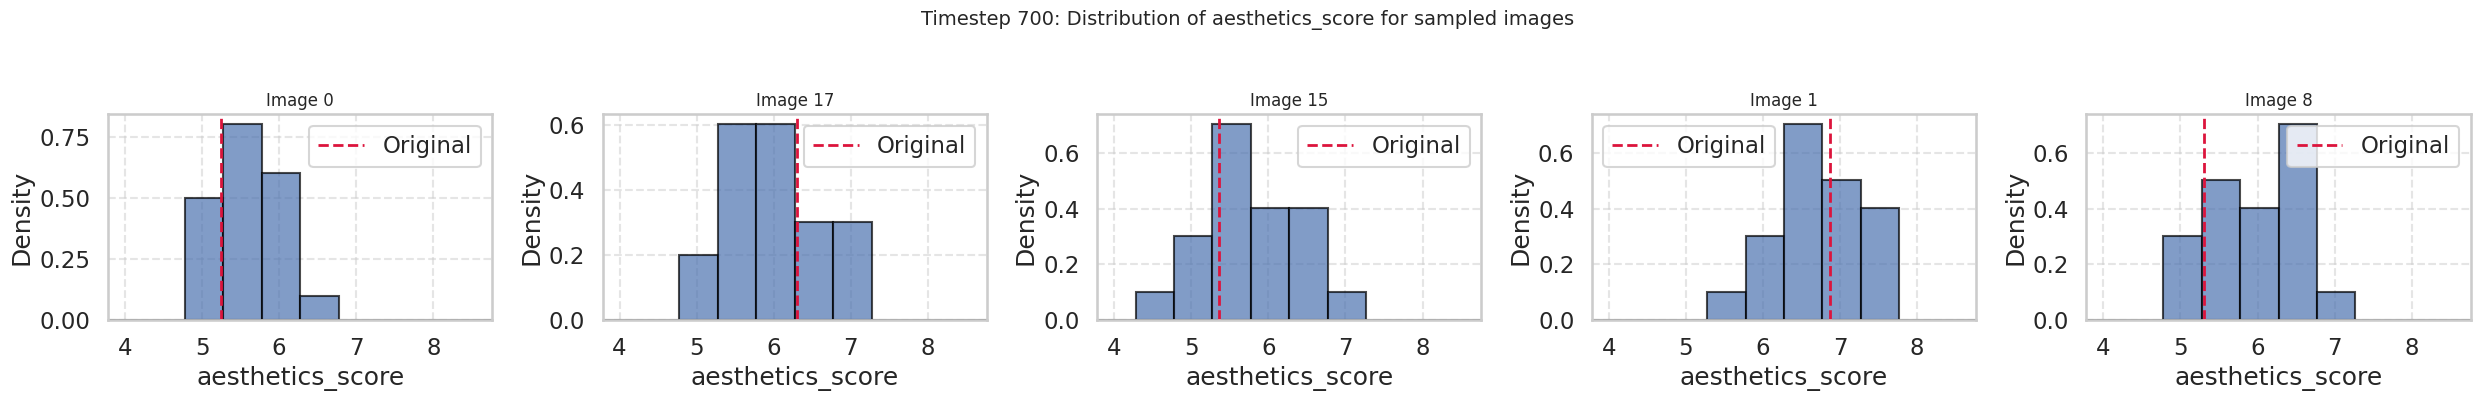

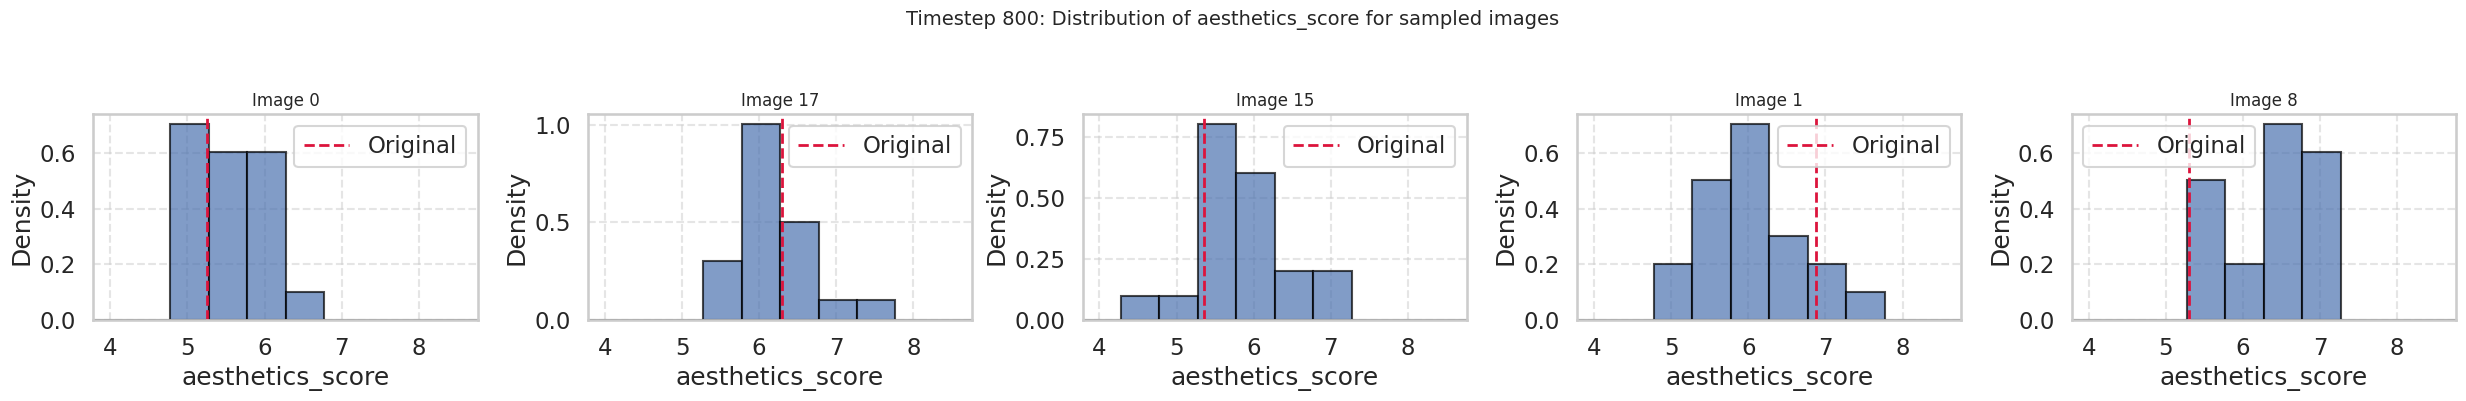

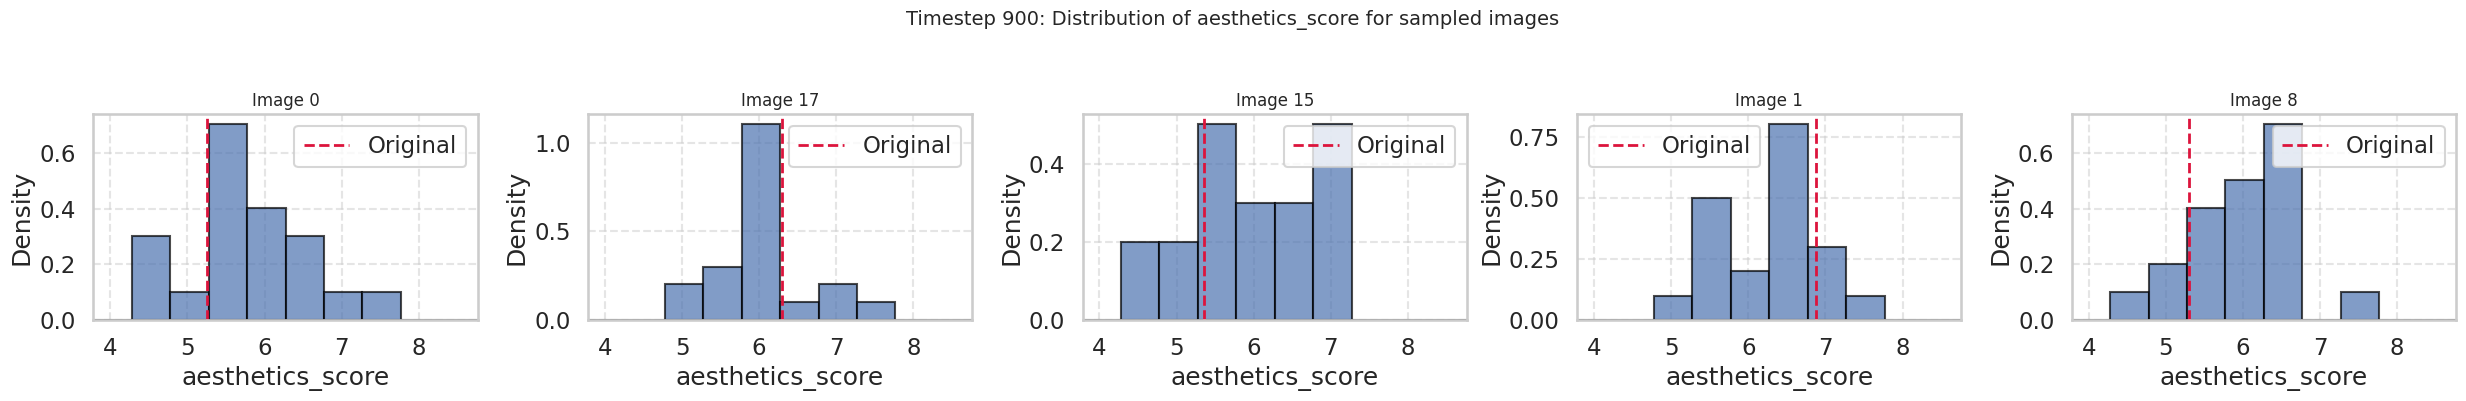

In [12]:
# Dataframe and metric to plot
df = all_data
metric_col = "aesthetics_score"

# Determine available images that have denoised samples
unique_images = sorted(df[df["sample_idx"].notnull()]["image_idx"].unique())
n_images = len(unique_images)
n_to_sample = min(5, n_images)

# Use a fixed seed so the same 5 images are chosen every run (change/remove seed for different random draws)
np.random.seed(42)
if n_to_sample > 0:
    sampled_images = list(np.random.choice(unique_images, size=n_to_sample, replace=False))
else:
    sampled_images = []

print(f"Randomly sampled images (same across timesteps): {sampled_images}")

# Choose timesteps to plot (stride 5)
selected_timesteps = [t for i, t in enumerate(timesteps) if i % 5 == 0]
print(f"Selected timesteps for histograms: {selected_timesteps}")

# Determine bin edges from RANGES if available, else fallback to data-driven range
try:
    value_min, value_max = RANGES.get(metric_col, (None, None))
except NameError:
    value_min, value_max = (None, None)
if value_min is None or value_max is None:
    col = df[metric_col].dropna()
    value_min = float(col.min())
    value_max = float(col.max())
if value_max <= value_min:
    value_max = value_min + 1e-6
# Fixed num bins (10) -> 11 edges
num_bins = 10
bins = np.linspace(value_min, value_max, num_bins + 1)

# Plot one figure per selected timestep with one subplot per sampled image
for t in selected_timesteps:
    if not sampled_images:
        print("No images with denoised samples found.")
        break

    n_sample = len(sampled_images)
    fig, axes = plt.subplots(1, n_sample, figsize=(5 * n_sample, 4), squeeze=False)

    for i, img_idx in enumerate(sampled_images):
        t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == t) & (df["image_idx"] == img_idx)]
        samples = t_df[metric_col].values
        ax = axes[0, i]

        if samples.size == 0:
            # No denoised samples for this image/timestep
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
            ax.set_title(f"Image {img_idx}", fontsize=12)
            ax.set_xlabel(metric_col)
            ax.set_ylabel("Density")
            ax.set_xlim(value_min, value_max)
            ax.grid(True, linestyle="--", alpha=0.5)
            continue

        # Plot histogram for this image at this timestep using metric-specific bins
        ax.hist(samples, bins=bins, density=True, alpha=0.7, edgecolor='black')

        # If original (sample_idx is null) value exists, mark it
        orig_row = df[(df["sample_idx"].isnull()) & (df["image_idx"] == img_idx)]
        if not orig_row.empty:
            orig_value = orig_row[metric_col].values[0]
            ax.axvline(orig_value, color="crimson", linestyle="--", linewidth=2, label="Original")
            ax.legend(frameon=True)

        ax.set_title(f"Image {img_idx}", fontsize=12)
        ax.set_xlabel(metric_col)
        ax.set_ylabel("Density")
        ax.set_xlim(value_min, value_max)
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.suptitle(f"Timestep {t}: Distribution of {metric_col} for sampled images", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Generate GIFS

In [13]:
# n_workers = len(csv_files)
# images_per_worker = all_data['image_idx'].nunique() // len(csv_files)
# print(f"Found {n_workers} workers and {images_per_worker} images per worker")
# for worker_id in range(len(csv_files)):
#     for image_id in range(images_per_worker):
#         make_reconstruction_gif(worker_id=worker_id, image_id=image_id, plot_dir=BASE_DIR, timesteps=timesteps, num_samples=20)